# Extract clips from Xenocanto Snapshot (including negatives)

env opso12 (Python 3.11.14)\
Back in the bioacousitcs-cookbook you can find a version of this notebook that works with a lat/long filter for negatives.\
 The notebook below has been modified (with Santiagos help) to extract negative clips based on specific target species eBird codes. You can also create a target (positive) dataset in this notebook, but if you already hand annotated your positives, just ignore the target_df at the end.

In [1]:
import sys
#sys.path.append("/home/gak76/.local/lib/python3.11/site-packages")

from pathlib import Path
from tqdm.autonotebook import tqdm
import pandas as pd
import datasets
from opensoundscape import annotations

/tmp/ipykernel_915905/244537785.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:

# Make sure to dont change this, otherwise you will donwload the whole dataset again
cache_dir = "/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache" 
ds = datasets.load_dataset(
    "DBD-research-group/BirdSet",
    "XCL",
    cache_dir=cache_dir, 
)
t = ds["train"]

print("The number of recordings in the dataset is", len(t))

Using the latest cached version of the dataset since DBD-research-group/BirdSet couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'XCL' at /media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/DBD-research-group___bird_set/XCL/0.0.4/c6d7d1c30e4d8f29c4fb5e358bc605ccb896681b869398c54db64721f45ac91e (last modified on Mon Nov 24 10:13:11 2025).


The number of recordings in the dataset is 528422


## Change first line depending of your target species

In [3]:
target="Virginia Rail"  # Replace with your target species name

# Read the file line by line and skip rows that cause decode errors
import io

#Clements taxonomy available at: https://www.birds.cornell.edu/clementschecklist/wp-content/uploads/2024/10/Clements-v2024-October-2024-rev.xlsx
ebird_path = "/media/auk/projects/srg/Kitzes_projects/ECOO53_CBAN_classifier/ebird_codes.txt"
good_lines = []
with open(ebird_path, "rb") as f:
    for line in f:
        try:
            good_lines.append(line.decode("utf-8"))
        except UnicodeDecodeError:
            continue

ebird_df = pd.read_csv(io.StringIO(''.join(good_lines)), sep="\t")
target_row = ebird_df[ebird_df["English name"] == target]
target_row

,species_code,English name,scientific name
4731,virrai,Virginia Rail,Rallus limicola


## Subset snapshot to recordings with your target species

In [4]:
# Make a new dataset object with just your target species recordings
target_ebird_code=str(target_row['species_code'].values[0])
label_feature = t.features["ebird_code"]

farewell_int = label_feature.str2int(target_ebird_code) 
filtered = t.filter(lambda example: example["ebird_code"] == farewell_int)

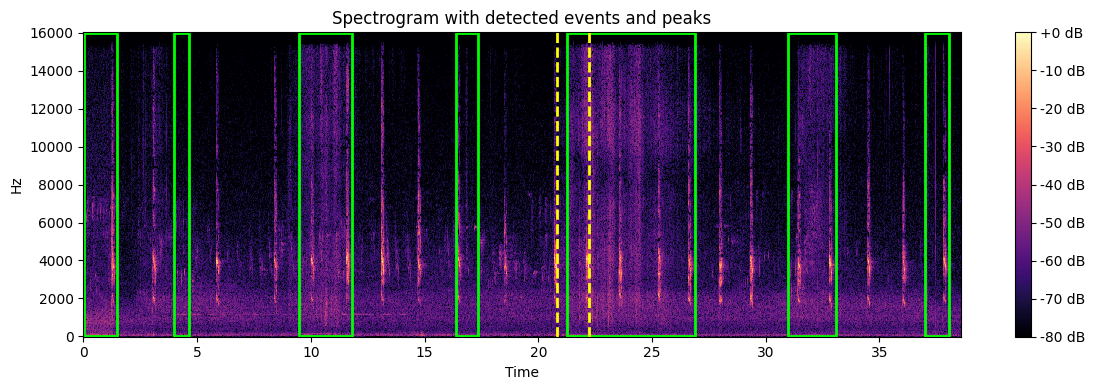

[[0.016, 1.488], [3.984, 4.64], [9.488, 11.792], [16.4, 17.36], [21.264, 26.88], [30.992, 33.104], [37.024, 38.064]]
[20.80589185694922, 22.21495549857364]


In [5]:
# Access an example
example = filtered[1]

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load the audio from the .ogg file
audio_path = example["filepath"]
y, sr = librosa.load(audio_path, sr=None)

# Calculate the spectrogram (mel or linear, up to you; use linear here)
S = librosa.stft(y, n_fft=1024, hop_length=256)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

# Set up the axes for time for drawing detected_events and peaks
duration = librosa.get_duration(y=y, sr=sr)
times = librosa.frames_to_time(np.arange(S_db.shape[1]), sr=sr, hop_length=256, n_fft=1024)

fig, ax = plt.subplots(figsize=(12, 4))
img = librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis='time', y_axis='hz', ax=ax)
plt.colorbar(img, ax=ax, format="%+2.0f dB")
ax.set_title("Spectrogram with detected events and peaks")

# Draw rectangles for each detected event [start, end]
for ev in example.get("detected_events", []):
    start, end = ev
    ax.add_patch(
        plt.Rectangle(
            (start, 0),  # (x,y)
            end - start,
            sr // 2,    # full frequency range (or np.max(S_db.shape[0]))
            color='lime',
            linewidth=2,
            fill=False
        )
    )

# Draw vertical lines for each peak
for peak in example.get("peaks", []):
    ax.axvline(peak, color='yellow', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

print(example["detected_events"])

print(example["peaks"])
from IPython.display import Audio, display

display(Audio(example['filepath']))

## Parameters you need to set before calling the audio files

In [7]:
#  TARGET SPECIES
# Duration of clips to extract
clip_duration = 1 #vira beg is .5 seconds

# Maximum number of events to extract (based on peaks)
max_events = 20

#  NEGATIVE SPECIES
# Maximum number of events to extract (based on peaks)
neg_max_events = 15

target_negatives = ["sora", "kinrai4", "y00475", "comgal1", "pibgre", "sonspa", "swaspa", "wilfly", "sancra", "rewbla", "marwre", "yelwar1", "grycat", "eawpew", "easkin", "reevir1", "bkcchi", "easpho", "killde", "reshaw", "rusbla", "comgra", "cedwax", "comyel", "sposan", "ribgul", "horgre", "amhgul1", "blujay", "rethaw"]  # Replace with actual eBird codes for negative species

In [8]:
target = []
negatives = []
print("Converting target_negatives to integers...")

# First convert all target_negatives to integers using the label_feature
target_negatives_int = [label_feature.str2int(code) for code in target_negatives]
print(f"Original target negatives: {target_negatives}")
print(f"Converted to integers: {target_negatives_int}")


Converting target_negatives to integers...
Original target negatives: ['sora', 'kinrai4', 'y00475', 'comgal1', 'pibgre', 'sonspa', 'swaspa', 'wilfly', 'sancra', 'rewbla', 'marwre', 'yelwar1', 'grycat', 'eawpew', 'easkin', 'reevir1', 'bkcchi', 'easpho', 'killde', 'reshaw', 'rusbla', 'comgra', 'cedwax', 'comyel', 'sposan', 'ribgul', 'horgre', 'amhgul1', 'blujay', 'rethaw']
Converted to integers: [1530, 1508, 1545, 1536, 1620, 8891, 8893, 4802, 1602, 8041, 8132, 6416, 7214, 4792, 4914, 5806, 7774, 4781, 1715, 2453, 6343, 6345, 9675, 6402, 1836, 1909, 1626, 1919, 6054, 2462]


In [9]:

for i in tqdm(range(len(t))):
    file = t[i]
    current_code = file['ebird_code']
    
    if file['ebird_code'] == farewell_int:
        detected_events = file["detected_events"].copy()

        if len(detected_events) < 1:
            detected_events = [[0, clip_duration]]
        elif len(detected_events) > max_events:
            detected_events = file["detected_events"][:max_events]

        for j, (start, end) in enumerate(detected_events):
            record = {
                "file": file["filepath"],
                "start_time": start,
                "annotation": file["ebird_code"],
                "quality": file['quality'],
            }
            target.append(record)

    elif current_code in target_negatives_int:  # Check against converted integers
        detected_events = file["detected_events"].copy()
        
        if len(detected_events) < 1:
            detected_events = [[0, clip_duration]]
        elif len(detected_events) > 3:
            detected_events = file["detected_events"][:neg_max_events]

        for j, (start, end) in enumerate(detected_events):
            record_other = {
                "file": file["filepath"],
                "start_time": start,
                "annotation": file["ebird_code"],
                "quality": file['quality'],
            }
            negatives.append(record_other)

print(f"Total target examples collected: {len(target)}")
print(f"Total negative examples collected: {len(negatives)}")

  0%|          | 0/528422 [00:00<?, ?it/s]

Total target examples collected: 1818
Total negative examples collected: 62966


In [19]:
target_df = pd.DataFrame(target)
negative_df = pd.DataFrame(negatives)

# convert integer annotation to list of one annotation per row
# this is the format used by annotations.categorical_to_multi_hot
target_df["annotation_list"] = [[x] for x in target_df["annotation"]]
negative_df["annotation_list"] = [[x] for x in negative_df["annotation"]]

In [20]:
# show columns and sample rows
print(negative_df.columns.tolist())
display(negative_df.head())

['file', 'start_time', 'annotation', 'quality', 'annotation_list']


,file,start_time,annotation,quality,annotation_list
0,/media/kiwi/datasets/annotated/xeno_canto_snap...,0.016,1530,B,[1530]
1,/media/kiwi/datasets/annotated/xeno_canto_snap...,2.832,1530,B,[1530]
2,/media/kiwi/datasets/annotated/xeno_canto_snap...,2.944,1530,B,[1530]
3,/media/kiwi/datasets/annotated/xeno_canto_snap...,5.744,1530,B,[1530]
4,/media/kiwi/datasets/annotated/xeno_canto_snap...,7.840,1530,B,[1530]


In [21]:
target_df.head(5)

,file,start_time,annotation,quality,annotation_list
0,/media/kiwi/datasets/annotated/xeno_canto_snap...,5.488,1509,A,[1509]
1,/media/kiwi/datasets/annotated/xeno_canto_snap...,9.296,1509,A,[1509]
2,/media/kiwi/datasets/annotated/xeno_canto_snap...,18.784,1509,A,[1509]
3,/media/kiwi/datasets/annotated/xeno_canto_snap...,28.416,1509,A,[1509]
4,/media/kiwi/datasets/annotated/xeno_canto_snap...,33.184,1509,A,[1509]


In [22]:
# generate multi-hot encoded dataframe for classifier training
multihot_labels_sparse, classes = annotations.categorical_to_multi_hot(
    negative_df["annotation_list"], sparse=True
)
ebird_classes = [
    t.info.features["ebird_code_multilabel"].feature.int2str(c) for c in classes
]
labels = pd.DataFrame.sparse.from_spmatrix(
    multihot_labels_sparse,
    index=pd.MultiIndex.from_frame(negative_df[["file", "start_time"]]),
    columns=ebird_classes,
)
OUTPUT_DIR = Path("/media/auk/projects/gak76/vira_beg_outputs/training_data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

labels.to_pickle(OUTPUT_DIR / "negative_multihot_labels_gk.pkl")


In [23]:
labels.head()

sora  kinrai4  \
file                                               start_time                  
/media/kiwi/datasets/annotated/xeno_canto_snaps... 0.016          1        0   
                                                   2.832          1        0   
                                                   2.944          1        0   
                                                   5.744          1        0   
                                                   7.840          1        0   

                                                               sancra  horgre  \
file                                               start_time                   
/media/kiwi/datasets/annotated/xeno_canto_snaps... 0.016            0       0   
                                                   2.832            0       0   
                                                   2.944            0       0   
                                                   5.744            0       0   
                                                   7.840            0       0   

                                                               comgal1  \
file                                               start_time            
/media/kiwi/datasets/annotated/xeno_canto_snaps... 0.016             0   
                                                   2.832             0   
                                                   2.944             0   
                                                   5.744             0   
                                                   7.840             0   

                                                               y00475  pibgre  \
file                                               start_time                   
/media/kiwi/datasets/annotated/xeno_canto_snaps... 0.016            0       0   
                                                   2.832            0       0   
                                                   2.944            0       0   
                                                   5.744            0       0   
                                                   7.840            0       0   

                                                               killde  sposan  \
file                                               start_time                   
/media/kiwi/datasets/annotated/xeno_canto_snaps... 0.016            0       0   
                                                   2.832            0       0   
                                                   2.944            0       0   
                                                   5.744            0       0   
                                                   7.840            0       0   

                                                               ribgul  ...  \
file                                               start_time          ...   
/media/kiwi/datasets/annotated/xeno_canto_snaps... 0.016            0  ...   
                                                   2.832            0  ...   
                                                   2.944            0  ...   
                                                   5.744            0  ...   
                                                   7.840            0  ...   

                                                               rusbla  comyel  \
file                                               start_time                   
/media/kiwi/datasets/annotated/xeno_canto_snaps... 0.016            0       0   
                                                   2.832            0       0   
                                                   2.944            0       0   
                                                   5.744            0       0   
                                                   7.840            0       0   

                                                               yelwar1  \
file                                               start_time            
/media/kiwi/data